In [1]:
import warnings

warnings.filterwarnings("ignore")

# QuantNado — Multi-Modal Dataset Exploration

This notebook walks through a complete analysis workflow using **QuantNado**: a toolkit for
efficient Zarr-backed storage and analysis of multi-modal genomic signal.

**Workflow covered:**
1. **Setup & Data** — Install dependencies and download test data
2. **Create Dataset** — Build unified multi-modal Zarr store from BAM/bedGraph/VCF files
3. **Load & Inspect** — Open the store and view available modalities
4. **Quality Control** — PCA, sample correlations, and data completeness overview
5. **Coverage Analysis** — Reduce signal over regions, feature counts, visualization
6. **Methylation Analysis** — CpG-level methylation, distribution, metaplots, tornado plots
7. **Variant Analysis** — Genotypes, allele frequencies, region-level filtering
8. **Multi-Modal Integration** — Locus browser and cross-modality comparisons

---

## Setup

> **Dependencies**  
> Install the optional example dependencies before running this notebook:
> ```bash
> pip install "quantnado[example]"
> ```
> This adds `ipykernel` and `matplotlib` on top of the core install.

In [2]:
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import quantnado as qn

## Data

The test dataset (BAM files, chr21 only) needs to be downloaded before running this notebook.
Run the cell below to fetch and extract it automatically, or manually:

```bash
# From the example/ directory
curl -L https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz \
  | tar -xz -C multiomics_run/

```

The reference files (`reference/chr21.gtf`, `reference/promoters_1024bp.bed`) are already included in the repository.

---

In [3]:
DATA_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz"
REF_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/reference.tar.gz"
RUN_DIR = Path("multiomics_run")
RUN_DIR.mkdir(parents=True, exist_ok=True)

for url in [DATA_URL, REF_URL]:
    filename = url.split("/")[-1]
    basename = filename.split(".tar.gz")[0]
    archive_path = RUN_DIR / filename
    outdir = RUN_DIR / basename
    if not outdir.exists():
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, archive_path)
        print(f"Extracting {filename}...")
        with tarfile.open(archive_path) as tf:
            tf.extractall(RUN_DIR)
        archive_path.unlink()
        print(f"Done with {filename}.")
    else:
        print(f"{filename} already present — skipping download.")

seqnado_output.tar.gz already present — skipping download.
reference.tar.gz already present — skipping download.


In [4]:
# Paths relative to this notebook (example/)
OUT_DIR = RUN_DIR / "seqnado_output"
REF_DIR = RUN_DIR / "reference"

MS_PATH = RUN_DIR / "dataset"  # MultiomicsStore directory
BED_FILE = str(REF_DIR / "promoters_1024bp.bed")
GTF_FILE = str(REF_DIR / "chr21.gtf")
FIG_DIR = RUN_DIR / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## Create a Unified Multi-Modal Dataset

`MultiomicsStore.from_files()` creates one directory (`dataset/`) containing a
sub-Zarr for each supplied modality:

| Sub-store | Input | What is stored |
|---|---|---|
| `coverage.zarr` | BAM files | per-base read depth (dense, sample × position) |
| `methylation.zarr` | MethylDackel bedGraph | CpG methylation % and counts (sparse) |
| `variants.zarr` | VCF.gz files | genotype, allele depths, quality (sparse) |

Run this cell once; it is skipped automatically if the store already exists.

In [5]:
# shutil.rmtree(MS_PATH, ignore_errors=True)

if not MS_PATH.exists():
    bam_files = sorted(OUT_DIR.rglob("*.bam"))
    bedgraph_files = sorted((OUT_DIR / "meth/methylation/methyldackel").glob("*.bedGraph"))
    vcf_files = sorted((OUT_DIR / "snp/variant").glob("*.vcf.gz"))
    meth_sample_names = [f.stem.split("_hg38")[0] for f in bedgraph_files]

    qn.create_dataset(
        store_dir=MS_PATH,
        bam_files=bam_files,
        bedgraph_files=bedgraph_files,
        vcf_files=vcf_files,
        bedgraph_sample_names=meth_sample_names,
        overwrite=True,
        resume=False,
        max_workers=4,
    )

else:
    print(f"Dataset already exists at {MS_PATH} — skipping creation.")

Dataset already exists at multiomics_run/dataset — skipping creation.


---
## Load and Inspect the Dataset

In [6]:
ds = qn.open(MS_PATH)
print(ds)

2026-03-07 21:27:28.076 | INFO     | quantnado.dataset.store_bam:_load_existing:498 - Resuming existing store at multiomics_run/dataset/coverage.zarr
2026-03-07 21:27:28.078 | INFO     | quantnado.dataset.store_methyl:_load_existing:178 - Resuming existing MethylStore at multiomics_run/dataset/methylation.zarr
2026-03-07 21:27:28.080 | INFO     | quantnado.dataset.store_variants:_load_existing:228 - Resuming existing VariantStore at multiomics_run/dataset/variants.zarr


MultiomicsStore at 'multiomics_run/dataset'
  modalities : ['coverage', 'methylation', 'variants']
  coverage    : 9 samples, 1 chrom(s)
  methylation : 2 samples, 1 chrom(s)
  variants    : 1 samples, 1 chrom(s)


In [7]:
print("Available modalities:", ds.modalities)
print("Chromosomes        :", ds.chromosomes)
print()

metadata = ds.get_metadata()
metadata

Available modalities: ['coverage', 'methylation', 'variants']
Chromosomes        : ['chr21']



,sample_hash,completed,sparsity,modalities
sample_id,,,,
atac,96ae824c5c35c004df1b9db3db07283e,True,99.904594,coverage
chip-rx_MLL,ea6b78070b8d28b7a0239eca45893bd4,True,95.253860,coverage
meth-rep1,f5ba0583afa25559ed30c9e8e2709f07,True,94.216675,"coverage, methylation"
meth-rep2,bcc7e3bf38ae81f6947662683190e221,True,93.745697,"coverage, methylation"
rna-spikein-control-rep1,2414b9280438e98f0c7cf50d5324bc2f,True,97.987144,coverage
rna-spikein-control-rep2,9b73f71b7438cdc6081be20663ee4929,True,98.167877,coverage
rna-spikein-treated-rep1,53da554c5e301439abe48b13b8838b67,True,96.408737,coverage
rna-spikein-treated-rep2,c2ac62c58d5c053b6f9400e46e08441f,True,96.751144,coverage
snp,e9eae880d15aaf4929da8db87d4dcb83,True,99.945015,"coverage, variants"


---
## Quality Control & Overview

Before diving into modality-specific analyses, let's assess data quality and get an overview of sample relationships.

### PCA on Promoter Signal

Principal component analysis reveals whether samples cluster by expected biological groupings
(e.g. assay type, treatment) and flags outliers. This is a standard QC step.

In [8]:
promoter_signal = ds.reduce(intervals_path=BED_FILE, reduction="mean")

pca_obj, pca_result = ds.pca(
    promoter_signal["mean"],
    n_components=8,
    nan_handling_strategy="drop",
)

2026-03-07 21:27:28.217 | INFO     | quantnado.analysis.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in BED/GTF file and 1 in dataset
2026-03-07 21:27:28.218 | DEBUG    | quantnado.analysis.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


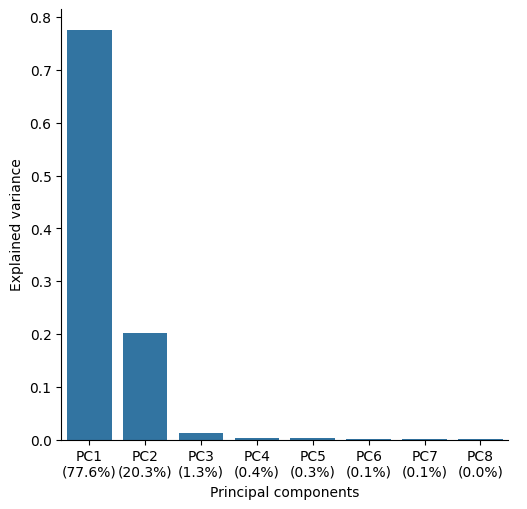

In [9]:
scree = qn.plot_pca_scree(pca_obj, filepath=FIG_DIR / "pca_scree.png")
plt.show()

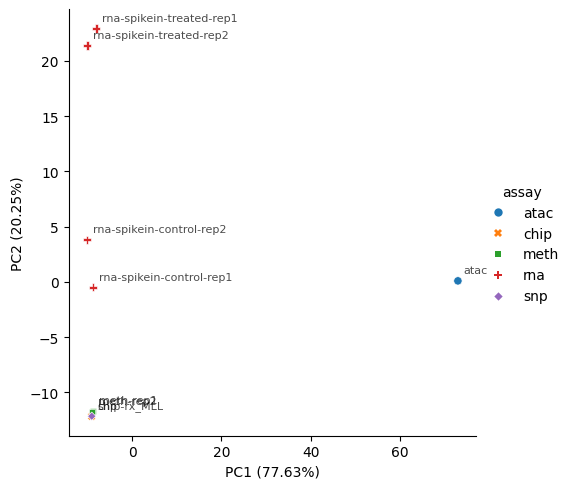

In [10]:
metadata["assay"] = metadata.index.str.split("-").str[0]

scatter = qn.plot_pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=metadata,
    colour_by="assay",
    shape_by="assay",
    height=5,
    filepath=FIG_DIR / "pca_scatter_pc1_pc2.png",
)
plt.show()

---
## Coverage Analysis

### Reduce Signal over Genomic Regions

Aggregate per-base signal across genomic intervals (e.g. promoters, peaks) to produce a
compact `(regions × samples)` matrix. Useful for downstream analysis such as PCA and clustering.

Reduction methods: `mean`, `sum`, `max`, `min`, `median`.

### Clustered Heatmap of Promoter Signal

Signal matrix shape: (1456, 9)  (regions × samples)
Dropped zero-variance samples: ['snp']


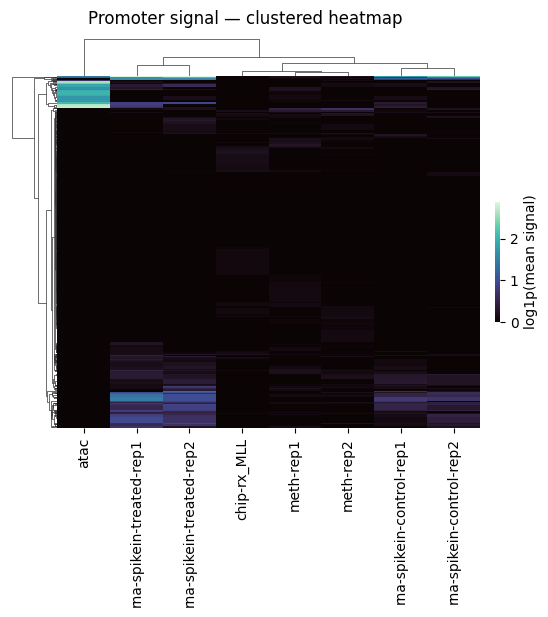

In [11]:
signal_matrix = promoter_signal["mean"].values
print(f"Signal matrix shape: {signal_matrix.shape}  (regions × samples)")

log_signal = np.log1p(signal_matrix)
sample_var = log_signal.var(axis=0)
keep = sample_var > 0
log_signal = log_signal[:, keep]
samples_informative = [s for s, k in zip(ds.samples, keep) if k]
if (~keep).any():
    dropped = [s for s, k in zip(ds.samples, keep) if not k]
    print(f"Dropped zero-variance samples: {dropped}")

g = sns.clustermap(
    log_signal,
    cmap="mako",
    yticklabels=False,
    xticklabels=samples_informative,
    figsize=(5, 6),
    col_cluster=True,
    row_cluster=True,
    cbar_kws={"label": "log1p(mean signal)"},
    cbar_pos=(1, 0.5, 0.01, 0.2),
    dendrogram_ratio=0.1,
)
g.figure.suptitle("Promoter signal — clustered heatmap", y=1.02)
g.savefig(FIG_DIR / "promoter_clustermap.png", bbox_inches="tight")
plt.show()

### Sample–Sample Correlation

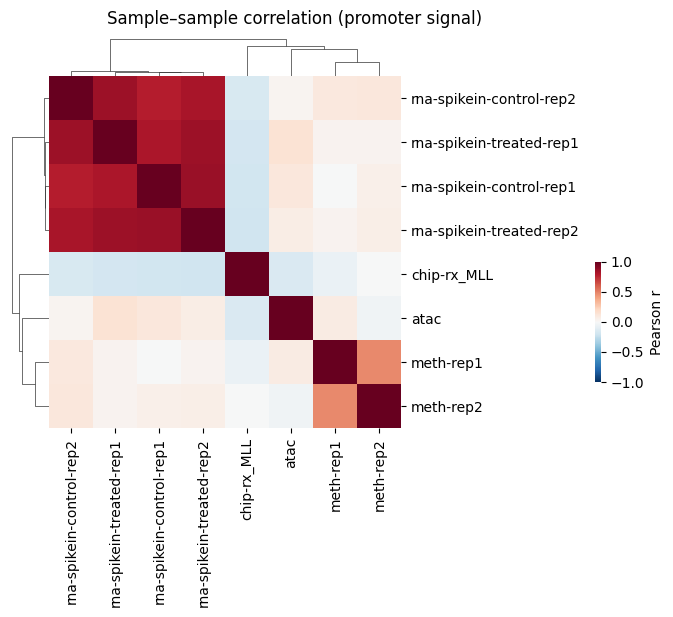

In [12]:
corr = np.corrcoef(log_signal.T)  # samples × samples

g = sns.clustermap(
    corr,
    xticklabels=samples_informative,
    yticklabels=samples_informative,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    figsize=(6, 6),
    cbar_kws={"label": "Pearson r"},
    cbar_pos=(1, 0.4, 0.01, 0.2),
    dendrogram_ratio=0.1,
)
g.figure.suptitle("Sample–sample correlation (promoter signal)", y=1.02)
g.figure.tight_layout()
g.savefig(FIG_DIR / "sample_correlation.png")
plt.show()

### Feature Count Matrix (DESeq2-compatible)

Sum signal across gene bodies to produce an integer count matrix ready for differential
expression analysis in DESeq2 or edgeR.

In [13]:
counts, features = ds.count_features(
    gtf_file=GTF_FILE,
    feature_type="transcript",
    feature_id_col=["gene_id", "transcript_id"],
    integerize=True,
)

print(f"Count matrix: {counts.shape[0]} genes × {counts.shape[1]} samples")
print(f"Feature metadata: {features.shape[0]} features × {features.shape[1]} columns")

2026-03-07 21:27:42.175 | INFO     | quantnado.analysis.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in input ranges and 1 in dataset
2026-03-07 21:27:42.176 | DEBUG    | quantnado.analysis.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


Count matrix: 986 genes × 9 samples
Feature metadata: 986 features × 7 columns


In [14]:
counts.loc["RUNX1"]

,atac,chip-rx_MLL,meth-rep1,meth-rep2,rna-spikein-control-rep1,rna-spikein-control-rep2,rna-spikein-treated-rep1,rna-spikein-treated-rep2,snp
transcript_id,,,,,,,,,
NM_001122607.2,0,3651,5413,7990,98,148,408,328,0
NM_001001890.3,0,5910,8215,11606,177,190,612,584,0
NM_001754.5,0,12417,34984,40866,1610,506,2340,4096,0


In [15]:
features.loc["RUNX1"]

,gene_id,transcript_id,contig,strand,start,end,range_length
transcript_id,,,,,,,
NM_001122607.2,RUNX1,NM_001122607.2,chr21,-,36193575,36260996,67421
NM_001001890.3,RUNX1,NM_001001890.3,chr21,-,36160097,36260996,100899
NM_001754.5,RUNX1,NM_001754.5,chr21,-,36160097,36421599,261502


In [16]:
counts_path = OUT_DIR / "counts_matrix.csv"
counts.to_csv(counts_path)
print(f"Counts saved to {counts_path}")

Counts saved to multiomics_run/seqnado_output/counts_matrix.csv


### Extract Raw Signal over Regions

`qn.extract()` returns the full per-position signal for each genomic interval as a
`(intervals × positions × samples)` DataArray — useful for metagene plots, coverage
tracks, and deep-learning feature engineering.

Setting `fixed_width` centres all intervals to the same length; `bin_size` downsamples
positions into coarser bins.

In [17]:
binned = ds.extract(
    modality="coverage",
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
)

print(binned)  # (intervals, bin, sample)

2026-03-07 21:27:47.891 | INFO     | quantnado.analysis.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in GTF and 1 in dataset
2026-03-07 21:27:47.891 | DEBUG    | quantnado.analysis.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


<xarray.DataArray 'getitem-6789307b2f7154fff5bd2da4bb132d35' (interval: 986,
                                                              bin: 40, sample: 9)> Size: 1MB
dask.array<getitem, shape=(986, 40, 9), dtype=float32, chunksize=(33, 40, 1), chunktype=numpy.ndarray>
Coordinates:
  * interval  (interval) int64 8kB 0 1 2 3 4 5 6 ... 979 980 981 982 983 984 985
    start     (interval) int64 8kB 46707966 46683849 ... 9733506 9689972
    end       (interval) int64 8kB 46717269 46707810 ... 9734109 9690726
    contig    (interval) <U5 20kB 'chr21' 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand    (interval) object 8kB '+' '-' '-' '-' '-' ... '+' '+' '+' '+' '-'
  * bin       (bin) int64 320B -1000 -950 -900 -850 -800 ... 750 800 850 900 950
  * sample    (sample) <U24 864B 'atac' 'chip-rx_MLL' ... 'snp'
Attributes:
    upstream:    1000
    downstream:  1000
    anchor:      start
    bin_size:    50
    bin_agg:     mean


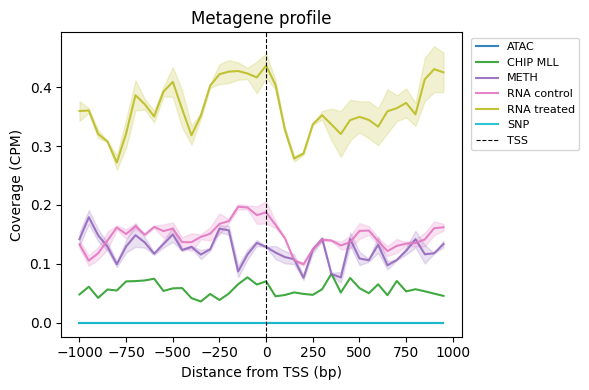

In [18]:
metadata["assay"] = metadata.index.to_series().apply(lambda s: s.split("-")[0])
metadata["condition"] = [
    "control" if "control" in s else "treated" if "treated" in s else "" for s in metadata.index
]
metadata["group"] = metadata["assay"].str.upper()
metadata.loc[metadata["assay"] == "rna", "group"] += " " + metadata["condition"]
metadata.loc[metadata["assay"] == "chip", "group"] += " MLL"
groups_dict = metadata.groupby("group").groups

ax = ds.metaplot(
    binned,
    modality="coverage",
    groups=groups_dict,
    flip_minus_strand=True,
    error_stat="sem",
    palette="tab10",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    title="Metagene profile",
    figsize=(6, 4),
    filepath=FIG_DIR / "metaplot.png",
)
plt.show()

#### Tornado plot (signal heatmap over TSSs)

Each row is one genomic interval (TSS ± window), colour encodes signal intensity.  
Intervals are sorted by mean signal of the first panel so all panels share the same row order.

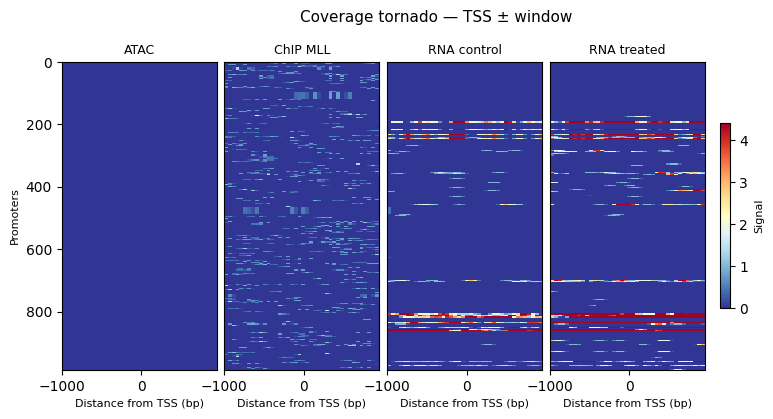

In [19]:
axes = ds.tornadoplot(
    binned,
    modality="coverage",
    samples=["atac", "chip-rx_MLL", "rna-spikein-control-rep1", "rna-spikein-treated-rep1"],
    sample_names=["ATAC", "ChIP MLL", "RNA control", "RNA treated"],
    flip_minus_strand=True,
    sort_by="mean",
    reference_point=None,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Promoters",
    title="Coverage tornado — TSS ± window",
    figsize=(10, 4),
    filepath=FIG_DIR / "tornado_tss.png",
)
plt.show()

#### Extract Signal for a Single Genomic Region

Use `extract_region` to pull the raw per-base coverage for any genomic locus across all samples.

In [20]:
runx1_coords = "chr21:34787801-34889760"
region = ds.extract_region(runx1_coords)
print(f"Region shape: {region.shape}  (samples × positions)")

2026-03-07 21:27:53.044 | INFO     | quantnado.dataset.store_bam:extract_region:1355 - Extracted region chr21:34787801-34889760 (101959 bp) for 9 sample(s)


Region shape: (9, 101959)  (samples × positions)


2026-03-07 21:27:53.106 | INFO     | quantnado.dataset.store_bam:extract_region:1355 - Extracted region chr21:34787801-34889760 (101959 bp) for 9 sample(s)


[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: xlabel='Position (chr21)'>]

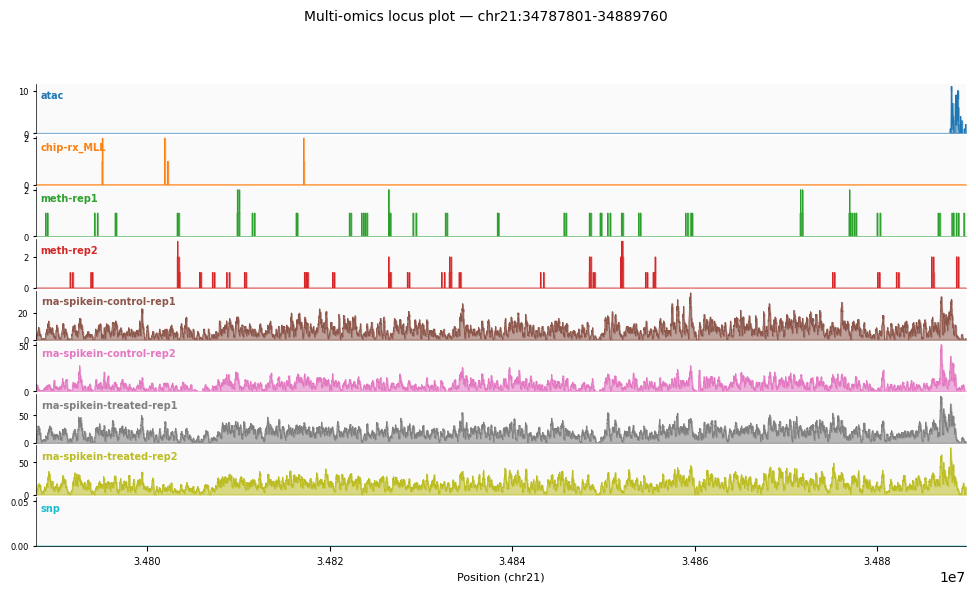

In [21]:
ds.locus_plot(
    locus=runx1_coords,
    sample_names=ds.samples,
    modality=["coverage"] * len(ds.samples),
    palette="tab10",
    title=f"Multi-omics locus plot — {runx1_coords}",
    figsize=(12, 6),
    filepath=FIG_DIR / "locus_plot.png",
)

---
## Methylation Analysis

`ms.methylation` is a `MethylStore` — a sparse Zarr store where each chromosome has:
- `positions` — the union of CpG start coordinates (0-based) across all samples
- `methylation_pct` — methylation percentage per site per sample (`NaN` = not covered)
- `n_methylated` / `n_unmethylated` — read counts

In [22]:
meth = ds.methylation
print(f"Samples : {meth.sample_names}")
for chrom in meth.chromosomes:
    print(f"  {chrom}: {len(meth.get_positions(chrom)):,} CpG sites")

meth_xr = meth.to_xarray(variable="methylation_pct")
print()
print(meth_xr["chr21"])

Samples : ['meth-rep1', 'meth-rep2']
  chr21: 19,751 CpG sites

<xarray.DataArray 'array-b15e15809889fe3f377a3543844cf5ce' (sample: 2,
                                                            position: 19751)> Size: 158kB
dask.array<array, shape=(2, 19751), dtype=float32, chunksize=(1, 19751), chunktype=numpy.ndarray>
Coordinates:
  * sample     (sample) <U9 72B 'meth-rep1' 'meth-rep2'
    completed  (sample) bool 2B True True
  * position   (position) int64 158kB 5067013 5067171 ... 46698163 46698204
Attributes:
    variable:    methylation_pct
    chromosome:  chr21


### Methylation distribution

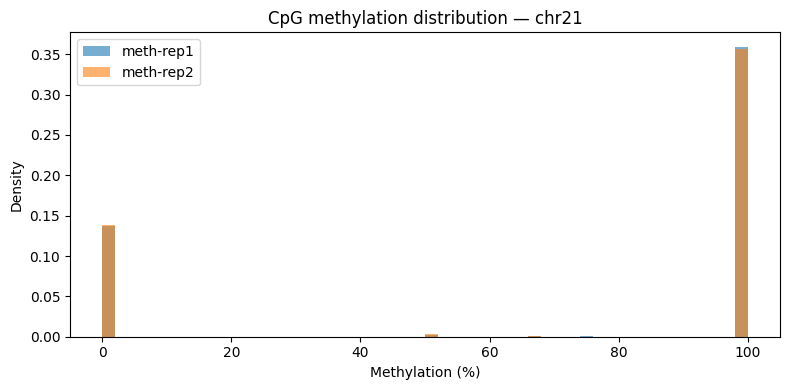

In [23]:
meth_data = meth_xr["chr21"].compute()

fig, ax = plt.subplots(figsize=(8, 4))
for sample in meth.sample_names:
    vals = meth_data.sel(sample=sample).values
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=50, alpha=0.6, label=sample, density=True)

ax.set_xlabel("Methylation (%)")
ax.set_ylabel("Density")
ax.set_title("CpG methylation distribution — chr21")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_distribution.png")
plt.show()

### Replicate correlation at shared CpG sites

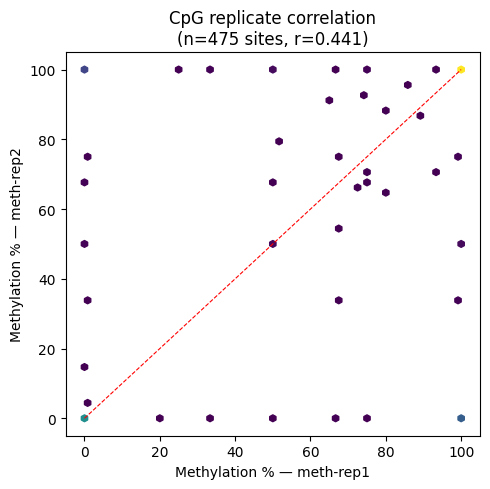

In [24]:
s1_name, s2_name = meth.sample_names[0], meth.sample_names[1]
s1 = meth_data.sel(sample=s1_name).values
s2 = meth_data.sel(sample=s2_name).values

covered = ~np.isnan(s1) & ~np.isnan(s2)
r = np.corrcoef(s1[covered], s2[covered])[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hexbin(s1[covered], s2[covered], gridsize=60, cmap="viridis", mincnt=1)
ax.plot([0, 100], [0, 100], "r--", linewidth=0.8)
ax.set_xlabel(f"Methylation % — {s1_name}")
ax.set_ylabel(f"Methylation % — {s2_name}")
ax.set_title(f"CpG replicate correlation\n(n={covered.sum():,} sites, r={r:.3f})")
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_replicate_correlation.png")
plt.show()

### Extract methylation over a specific region

In [25]:
stats, features = ds.methylation.count_features(
    gtf_file=GTF_FILE,
    feature_type="transcript",
    feature_id_col=["gene_id", "transcript_id"],
    integerize=True,
)

print(f"Available stats: {list(stats.keys())}")
print(f"Features: {features.shape}")

stats.keys()

Available stats: ['n_methylated', 'n_unmethylated', 'n_cpg_covered', 'methylation_ratio', 'methylation_pct']
Features: (1087, 8)


dict_keys(['n_methylated', 'n_unmethylated', 'n_cpg_covered', 'methylation_ratio', 'methylation_pct'])

### Methylation Feature Counts

Similar to coverage feature counting, you can aggregate methylation statistics over genomic features.

In [26]:
region_meth = meth.extract_region(runx1_coords, variable="methylation_pct")
print(f"Shape: {region_meth.shape}  (samples × CpG sites in RUNX1)")
print(f"CpG positions covered: {(~np.isnan(region_meth.values)).sum(axis=1)}")

Shape: (2, 82)  (samples × CpG sites in RUNX1)
CpG positions covered: [58 28]


### Methylation metaplot over promoters

For each 1024 bp promoter window on chr21, CpG sites are assigned to one of 32 bins
relative to the TSS (position 0). Minus-strand promoters are strand-corrected so that
the TSS is always at the centre. The profile shows mean methylation % per bin across all
promoters.

### Methylation Signal Visualization

Extract methylation % over genomic intervals and visualize as metaplots and tornado plots,
similar to the coverage visualizations above.

In [27]:
binned_meth = ds.extract(
    modality="methylation",
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
)

2026-03-07 21:27:55.710 | INFO     | quantnado.analysis.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in intervals and 1 in dataset
2026-03-07 21:27:55.711 | DEBUG    | quantnado.analysis.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


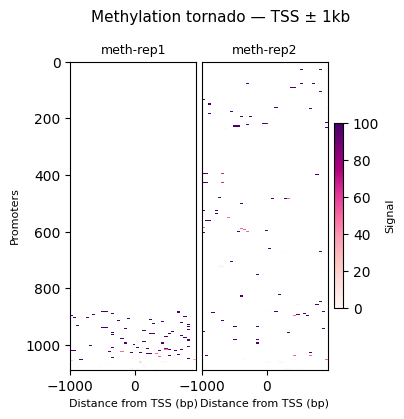

In [28]:
axes = ds.tornadoplot(
    binned_meth,
    modality="methylation",
    flip_minus_strand=True,
    sort_by="mean",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Promoters",
    title="Methylation tornado — TSS ± 1kb",
    figsize=(4, 4),
    filepath=FIG_DIR / "tornado_tss_methylation.png",
)
plt.show()

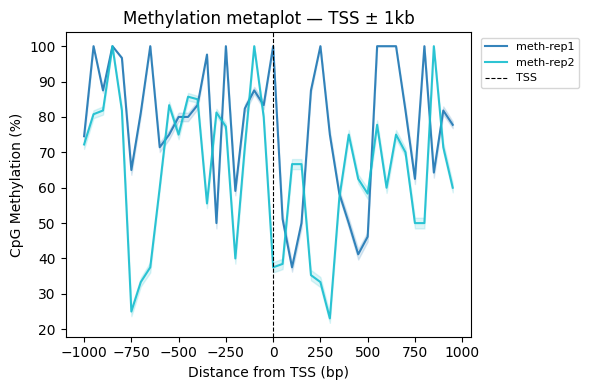

In [29]:
ax = ds.metaplot(
    binned_meth,
    modality="methylation",
    flip_minus_strand=True,
    error_stat="sem",
    palette="tab10",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="CpG Methylation (%)",
    title="Methylation metaplot — TSS ± 1kb",
    figsize=(6, 4),
    filepath=FIG_DIR / "metaplot_methylation.png",
)
plt.show()

[<Axes: >, <Axes: xlabel='Position (chr21)'>]

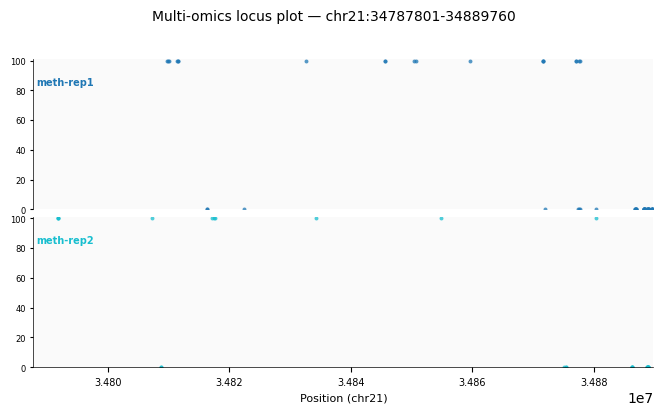

In [30]:
ds.locus_plot(
    locus=runx1_coords,
    sample_names=["meth-rep1", "meth-rep2"],
    modality=["methylation"] * 2,
    palette="tab10",
    title=f"Multi-omics locus plot — {runx1_coords}",
    figsize=(8, 4),
    filepath=FIG_DIR / "locus_plot_methylation.png",
)

---
## Variant Analysis

`msstore_variants` is a `VariantStore` — a sparse Zarr store where each chromosome has:
- `positions` — 1-based variant positions (union across all samples)
- `genotype` — integer encoded: `-1` missing, `0` hom-ref, `1` het, `2` hom-alt
- `allele_depth_ref` / `allele_depth_alt` — read depths per allele
- `qual` — per-sample variant quality score

In [31]:
var = ds.variants
print(f"Samples : {var.sample_names}")
for chrom in var.chromosomes:
    print(f"  {chrom}: {len(var.get_positions(chrom)):,} variant sites")

gt_xr = var.to_xarray(variable="genotype")
print()
print(gt_xr["chr21"])

Samples : ['snp']
  chr21: 148 variant sites

<xarray.DataArray 'array-6a9234c7c1ce7dcac3dfa9cbb9895f17' (sample: 1,
                                                            position: 148)> Size: 148B
dask.array<array, shape=(1, 148), dtype=int8, chunksize=(1, 148), chunktype=numpy.ndarray>
Coordinates:
  * sample     (sample) <U3 12B 'snp'
    completed  (sample) bool 1B True
  * position   (position) int64 1kB 5230802 5230815 ... 13918697 13950515
Attributes:
    variable:    genotype
    chromosome:  chr21


### Genotype summary

In [32]:
gt_data = gt_xr["chr21"].compute()

labels = {-1: "missing", 0: "hom-ref", 1: "het", 2: "hom-alt"}
print("Genotype counts per sample:")
for sample in var.sample_names:
    gt = gt_data.sel(sample=sample).values
    counts = {labels[k]: int((gt == k).sum()) for k in [-1, 0, 1, 2]}
    print(f"  {sample}: {counts}")

Genotype counts per sample:
  snp: {'missing': 0, 'hom-ref': 0, 'het': 125, 'hom-alt': 23}


### Variants in a specific region

In [38]:
REGION = "chr21:5230000-5250000"

region_gt = var.extract_region(REGION, variable="genotype")
region_qual = var.extract_region(REGION, variable="qual")
region_ad_r = var.extract_region(REGION, variable="allele_depth_ref")
region_ad_a = var.extract_region(REGION, variable="allele_depth_alt")

positions = region_gt.coords["position"].values
ref_alleles, alt_alleles = var.get_alleles("chr21")
# subset alleles to positions in this region
all_pos = var.get_positions("chr21")
pos_mask = (all_pos >= int(REGION.split(":")[1].split("-")[0])) & (
    all_pos <= int(REGION.split("-")[1])
)
refs_reg = [ref_alleles[i] for i in np.where(pos_mask)[0]]
alts_reg = [alt_alleles[i] for i in np.where(pos_mask)[0]]

# Build a tidy DataFrame for the first sample
sample = var.sample_names[0]
df_region = pd.DataFrame(
    {
        "pos": positions,
        "ref": refs_reg,
        "alt": alts_reg,
        "genotype": [labels[g] for g in region_gt.sel(sample=sample).values],
        "qual": region_qual.sel(sample=sample).values.round(1),
        "AD_ref": region_ad_r.sel(sample=sample).values,
        "AD_alt": region_ad_a.sel(sample=sample).values,
    }
)
print(f"Variants in {REGION} for sample '{sample}':")
print(df_region)

Variants in chr21:5230000-5250000 for sample 'snp':
       pos   ref       alt genotype        qual  AD_ref  AD_alt
0  5230802     T         A      het    9.800000       3       6
1  5230815  taaa  tAAACaaa      het    4.600000       6       6
2  5230840     C         A      het   20.500000      10       6
3  5230899     T         C  hom-alt  225.399994       0      22
4  5230907     A         G      het   34.900002      13       9
5  5230914     T         C      het  220.500000       4      18
6  5230949     A         G  hom-alt  172.399994       1      13
7  5230965     T         C      het   16.600000       8       5
8  5230984     C         G      het    9.700000       7       4


Plotting 9 variants in chr21:5230000-5250000


[<Axes: xlabel='Position (chr21)'>]

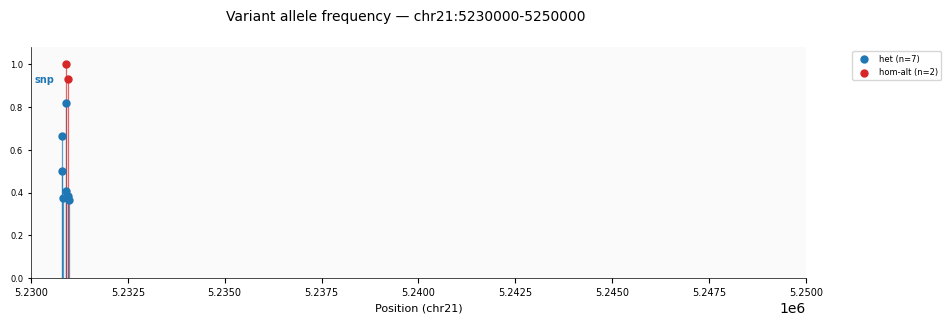

In [39]:
# Use the REGION with known variants from above
gt_region = var.extract_region(REGION, variable="genotype")
adr_region = var.extract_region(REGION, variable="allele_depth_ref")
ada_region = var.extract_region(REGION, variable="allele_depth_alt")

print(f"Plotting {gt_region.shape[1]} variants in {REGION}")

ds.locus_plot(
    locus=REGION,
    genotype=gt_region,
    allele_depth_ref=adr_region,
    allele_depth_alt=ada_region,
    sample_names=["snp"],
    modality=["variant"],
    title=f"Variant allele frequency — {REGION}",
    figsize=(10, 3),
    filepath=FIG_DIR / "locus_plot_variants.png",
)

---
## Multi-Modal Integration

### Multi-Modal Locus Browser

View all three modalities together for a single genomic region — the same layout as a genome
browser, built directly from the `MultiomicsStore` in a few lines.

Panels (top → bottom, all sharing the same x-axis):
- **Coverage** tracks for selected assay types (ATAC, ChIP, methylation, SNP)
- **Methylation %** at individual CpG sites (one dot per site, per replicate)
- **Variant allele frequency** coloured by genotype (blue = het, red = hom-alt)

2026-03-07 21:27:56.569 | INFO     | quantnado.dataset.store_bam:extract_region:1355 - Extracted region chr21:34787801-34889760 (101959 bp) for 9 sample(s)


[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: xlabel='Position (chr21)'>]

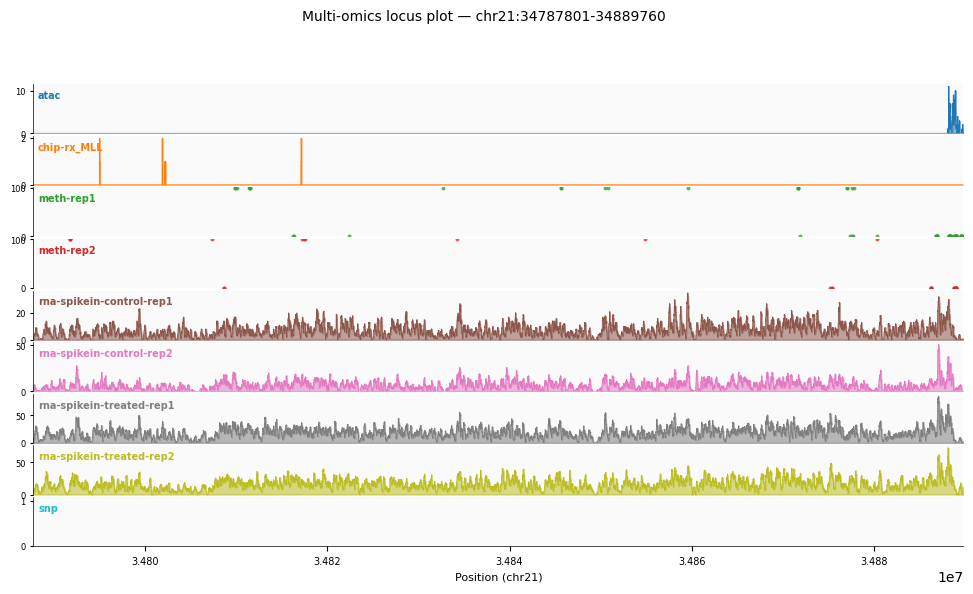

In [35]:
gt = ds.variants.extract_region(runx1_coords, variable="genotype").compute()
adr = ds.variants.extract_region(runx1_coords, variable="allele_depth_ref").compute()
ada = ds.variants.extract_region(runx1_coords, variable="allele_depth_alt").compute()

ds.locus_plot(
    locus=runx1_coords,
    genotype=gt,
    allele_depth_ref=adr,
    allele_depth_alt=ada,
    sample_names=ds.samples,
    modality=[
        "coverage",
        "coverage",
        "methylation",
        "methylation",
        "coverage",
        "coverage",
        "coverage",
        "coverage",
        "variant",
    ],
    palette="tab10",
    title=f"Multi-omics locus plot — {runx1_coords}",
    figsize=(12, 6),
    filepath=FIG_DIR / "locus_plot.png",
)